# Tasks Unsolved by All Experiments

This notebook identifies the sampled ARC tasks that none of the five experimental conditions solved. It loads task-level outcome records, finds tasks with zero successful experiments, saves the all-unsolved task list, and provides a quick difficulty-distribution visualization.


## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image as DisplayImage, display


def resolve_project_root() -> Path:
    """Walk upward from cwd until we find a directory that contains final_outputs/."""
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "final_outputs").is_dir():
            return candidate
        legacy = candidate / "sample" / "final_outputs"
        if legacy.is_dir():
            return candidate / "sample"
    raise FileNotFoundError(
        "Could not locate experiment outputs. Expected a `final_outputs` directory "
        "(at the project root or under `sample/`). Unzip `final_outputs.zip` if needed, "
        "and run the notebook with the working directory inside the repo (e.g. open "
        "the project folder in Cursor/Jupyter)."
    )


ROOT = resolve_project_root()
print(f"Project root: {ROOT}")


Project root: /Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation


## 2. Helper functions

This section defines the data-loading, metric-computation, CSV-writing, and plotting functions used in the analysis below.


In [2]:
import csv
from collections import defaultdict
from pathlib import Path
from typing import Any


# ROOT is defined in the setup cell.
INPUT_PATH = ROOT / "analysis_outputs" / "task_outcomes_by_experiment.csv"
OUTPUT_PATH = ROOT / "analysis_outputs" / "all_experiments_unsolved_tasks.csv"

EXPERIMENT_FOLDERS = [
    "0_output_grid",
    "1_program_only",
    "2_hypo_program",
    "3_hint_hypo_program",
    "4_good_hypo_program",
]


def bool_value(value: Any) -> bool:
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def main() -> None:
    with INPUT_PATH.open("r", encoding="utf-8-sig", newline="") as f:
        rows = list(csv.DictReader(f))

    by_task: dict[str, list[dict[str, str]]] = defaultdict(list)
    for row in rows:
        by_task[row["task_id"]].append(row)

    output_rows: list[dict[str, Any]] = []
    for task_id, task_rows in by_task.items():
        task_rows_by_experiment = {
            row["experiment_folder"]: row for row in task_rows
        }
        if any(bool_value(row["task_correct"]) for row in task_rows):
            continue

        first = task_rows[0]
        out: dict[str, Any] = {
            "task_id": task_id,
            "difficulty": first["difficulty"],
        }
        for folder in EXPERIMENT_FOLDERS:
            row = task_rows_by_experiment[folder]
            out[f"{folder}_correct_examples"] = row["correct_test_examples"]
            out[f"{folder}_test_examples"] = row["test_examples"]
            out[f"{folder}_example_accuracy"] = row["example_accuracy"]
        output_rows.append(out)

    difficulty_rank = {"Easy": 0, "Medium": 1, "Hard": 2, "Expert": 3}
    output_rows.sort(
        key=lambda row: (difficulty_rank.get(row["difficulty"], 99), row["task_id"])
    )

    fieldnames = [
        "task_id",
        "difficulty",
    ]
    for folder in EXPERIMENT_FOLDERS:
        fieldnames.extend(
            [
                f"{folder}_correct_examples",
                f"{folder}_test_examples",
                f"{folder}_example_accuracy",
            ]
        )

    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    with OUTPUT_PATH.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(output_rows)

    print(f"Wrote {len(output_rows)} all-unsolved tasks to {OUTPUT_PATH}")


## 3. Load task-level outcomes

In [3]:
task_outcomes = pd.read_csv(INPUT_PATH)
print(task_outcomes.shape)
display(task_outcomes.head())
display(task_outcomes.groupby("experiment_name").agg(tasks=("task_id", "count"), solved=("task_correct", "sum")))

(500, 9)


,experiment_order,experiment_folder,experiment_name,task_id,difficulty,test_examples,correct_test_examples,example_accuracy,task_correct
0,0,0_output_grid,Direct Output Grid,025d127b,Easy,1,1,1.0,True
1,0,0_output_grid,Direct Output Grid,0a938d79,Easy,1,0,0.0,False
2,0,0_output_grid,Direct Output Grid,0b148d64,Easy,1,0,0.0,False
3,0,0_output_grid,Direct Output Grid,0d3d703e,Easy,1,0,0.0,False
4,0,0_output_grid,Direct Output Grid,150deff5,Easy,1,0,0.0,False


,tasks,solved
experiment_name,,
Direct Output Grid,100,11
High Quality Hypothesis + Program,100,82
Hint + Hypothesis + Program,100,38
Hypothesis + Program,100,25
Program Only,100,30


## 4. Identify tasks solved by none of the experiments

In [4]:
matrix = task_outcomes.pivot_table(index=["task_id", "difficulty"], columns="experiment_folder", values="task_correct", aggfunc="first").reset_index()
for folder in EXPERIMENT_FOLDERS:
    matrix[folder] = matrix[folder].astype(str).str.lower().isin(["true", "1"])
all_unsolved = matrix.loc[~matrix[EXPERIMENT_FOLDERS].any(axis=1), ["task_id", "difficulty"]].copy()
print(f"All-unsolved tasks: {len(all_unsolved)}")
display(all_unsolved)
display(all_unsolved["difficulty"].value_counts().reindex(["Easy", "Medium", "Hard", "Expert"], fill_value=0).rename("all_unsolved_count").to_frame())

All-unsolved tasks: 16


experiment_folder,task_id,difficulty
5,150deff5,Easy
8,1f0c79e5,Expert
17,28e73c20,Easy
20,39e1d7f9,Easy
30,4be741c5,Medium
32,50846271,Hard
37,5daaa586,Medium
38,60b61512,Easy
48,776ffc46,Easy
59,97a05b5b,Medium


,all_unsolved_count
difficulty,
Easy,9
Medium,4
Hard,2
Expert,1


## 5. Add example-level details and save CSV

In [5]:
detail_rows = []
for _, task_row in all_unsolved.iterrows():
    rows_for_task = task_outcomes[task_outcomes["task_id"] == task_row["task_id"]].set_index("experiment_folder")
    out = {"task_id": task_row["task_id"], "difficulty": task_row["difficulty"]}
    for folder in EXPERIMENT_FOLDERS:
        row = rows_for_task.loc[folder]
        out[f"{folder}_correct_examples"] = row["correct_test_examples"]
        out[f"{folder}_test_examples"] = row["test_examples"]
        out[f"{folder}_example_accuracy"] = row["example_accuracy"]
    detail_rows.append(out)
all_unsolved_detail = pd.DataFrame(detail_rows)
difficulty_rank = {"Easy": 0, "Medium": 1, "Hard": 2, "Expert": 3}
all_unsolved_detail = all_unsolved_detail.assign(difficulty_rank=all_unsolved_detail["difficulty"].map(difficulty_rank)).sort_values(["difficulty_rank", "task_id"]).drop(columns="difficulty_rank")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
all_unsolved_detail.to_csv(OUTPUT_PATH, index=False)
print(OUTPUT_PATH)
display(all_unsolved_detail)

/Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation/analysis_outputs/all_experiments_unsolved_tasks.csv


,task_id,difficulty,0_output_grid_correct_examples,0_output_grid_test_examples,0_output_grid_example_accuracy,1_program_only_correct_examples,1_program_only_test_examples,1_program_only_example_accuracy,2_hypo_program_correct_examples,2_hypo_program_test_examples,2_hypo_program_example_accuracy,3_hint_hypo_program_correct_examples,3_hint_hypo_program_test_examples,3_hint_hypo_program_example_accuracy,4_good_hypo_program_correct_examples,4_good_hypo_program_test_examples,4_good_hypo_program_example_accuracy
0,150deff5,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
2,28e73c20,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
3,39e1d7f9,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
7,60b61512,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
8,776ffc46,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
11,d07ae81c,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
12,e6721834,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
13,e73095fd,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
14,ec883f72,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
4,4be741c5,Medium,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0


## 6. Quick visualization

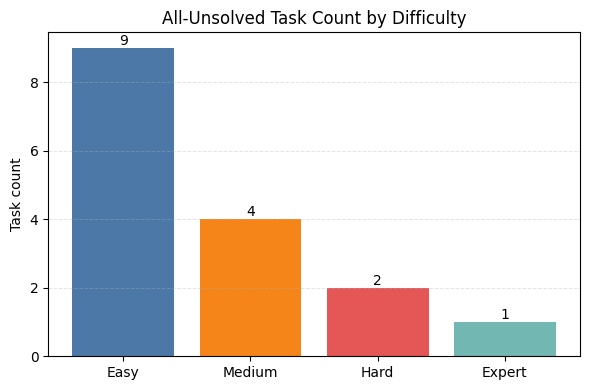

In [6]:
counts = all_unsolved_detail["difficulty"].value_counts().reindex(["Easy", "Medium", "Hard", "Expert"], fill_value=0)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=["#4C78A8", "#F58518", "#E45756", "#72B7B2"])
ax.bar_label(bars)
ax.set_title("All-Unsolved Task Count by Difficulty")
ax.set_ylabel("Task count")
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
fig.tight_layout()
display(fig)
plt.close(fig)